## Gold price predict Using Decision Tree Regressor

## Problem Statement
The objective of this project is to predict the closing price of gold using historical market data such as open, high, low prices, volume, and date-based features. By applying a Decision Tree Regressor, the model aims to capture patterns and relationships in price movements. This helps in understanding market trends and improving decision-making in financial analysis.

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization



## Import library 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error


## Loading the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\GoldUSD.csv")
df

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354


## Data Preprocessing

In [3]:
df.shape

(6399, 6)

In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0


In [6]:
df.tail()

,Date,Open,High,Low,Close,Volume
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354
6398,03-03-26,5335.700195,5394.200195,5334.899902,5377.299805,21189


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_17744\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek

## Data Visualization

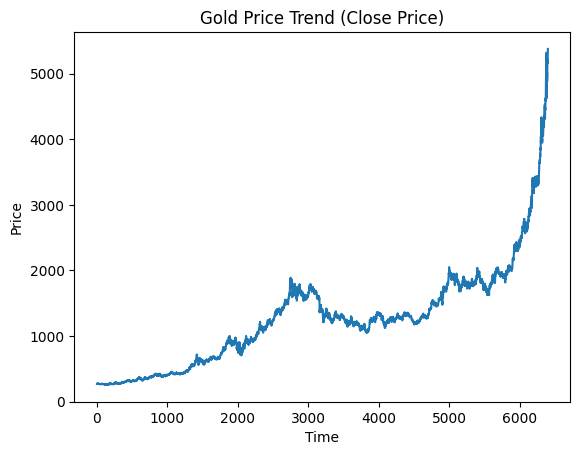

In [11]:
plt.figure()
plt.plot(df['Close'])
plt.title("Gold Price Trend (Close Price)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Observation:
The line plot shows the trend of gold prices over time, highlighting fluctuations and overall market movement.

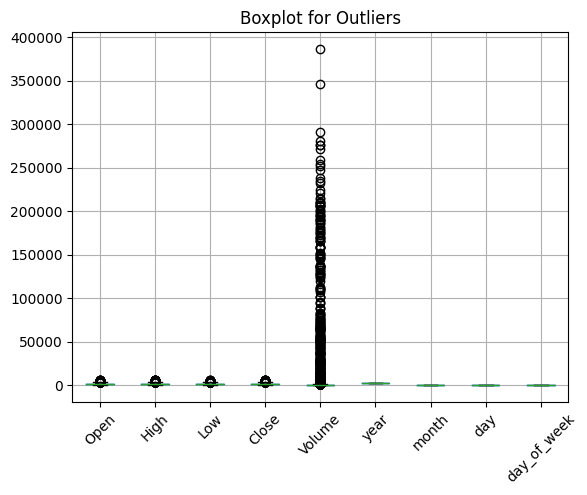

In [12]:
plt.figure()
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot for Outliers")
plt.show()

## Observation:
The boxplot helps identify outliers and shows the spread and distribution of numerical features in the dataset

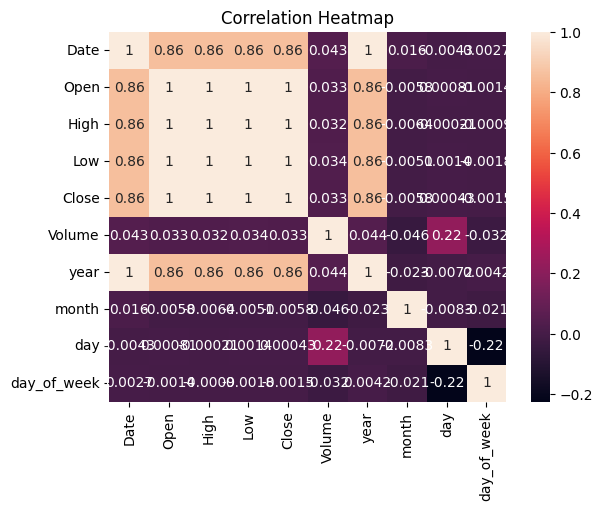

In [13]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Observation:
Price-related features are highly correlated, indicating strong relationships, while volume has weaker influence

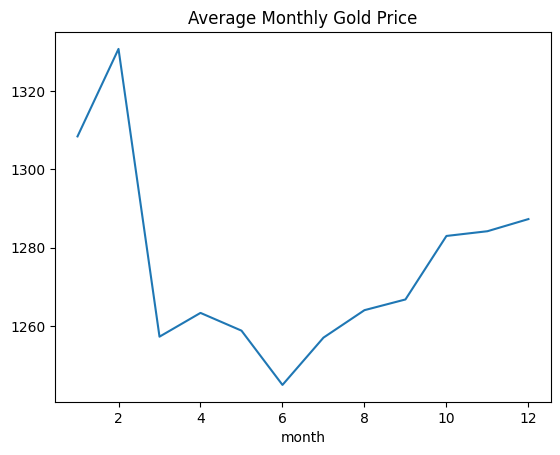

In [14]:
plt.figure()
df.groupby('month')['Close'].mean().plot()
plt.title("Average Monthly Gold Price")
plt.show()

## Observation:
The monthly trend shows variation in gold prices across months, indicating possible seasonal patterns.

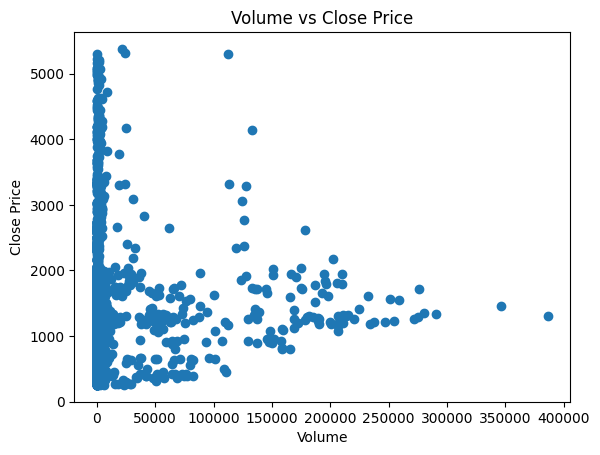

In [15]:
plt.figure()
plt.scatter(df['Volume'], df['Close'])
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.title("Volume vs Close Price")
plt.show()

## Observation:
Volume shows weak or no clear relationship with closing price, indicating it is not a strong predictor

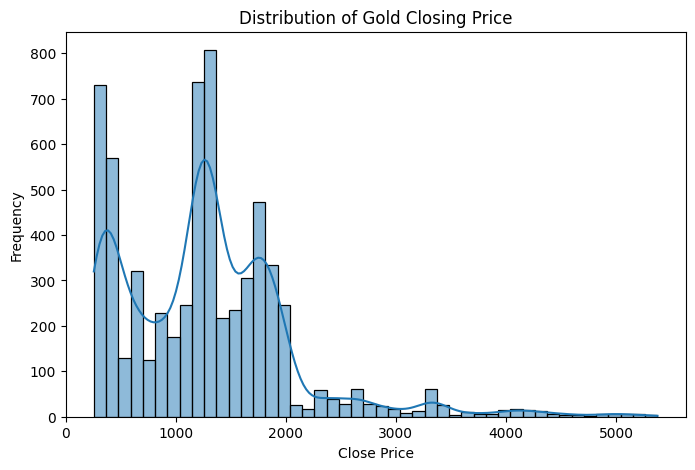

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], kde=True)
plt.title("Distribution of Gold Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

### Observation:
The closing price is concentrated at lower values with a right-skewed distribution.
This indicates that a smaller number of observations have significantly higher gold prices.

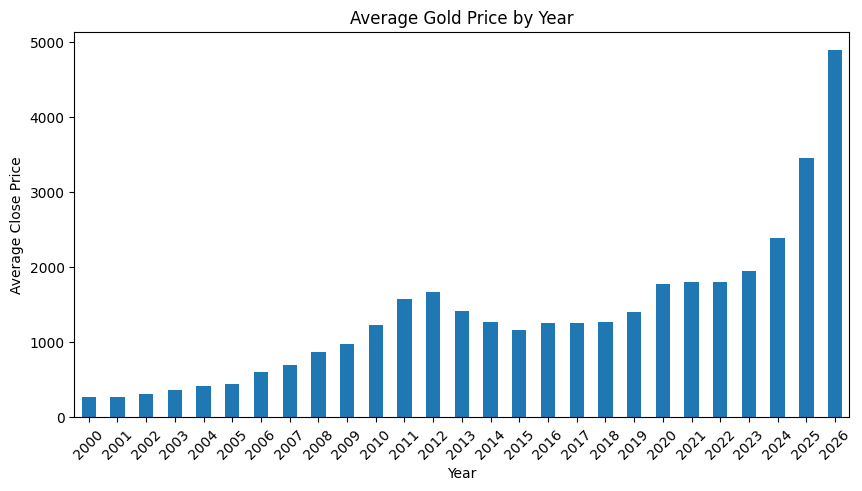

In [17]:
plt.figure(figsize=(10,5))

df.groupby('year')['Close'].mean().plot(kind='bar')

plt.title("Average Gold Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.show()

### Observation:
The average gold price shows an overall increasing trend over the years.
Gold prices are much higher in recent years compared with the earlier years.